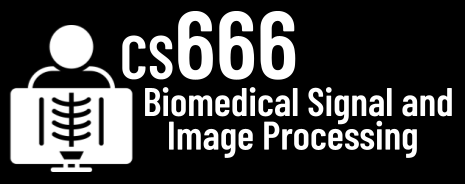
#Assignment 6

In [1]:
# NAME: Rami Huu Nguyen

In [2]:
# In this assignment, we will visualize and explore a CT scan!

In [3]:
# load numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [5]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [6]:
# TODO: YOUR CODE

In [7]:
!wget --user-agent="Mozilla/5.0" https://cs666.org/data/ct.zip

--2026-05-02 10:46:43--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  2.60MB/s    in 2.1s    

2026-05-02 10:46:46 (2.60 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [8]:
# Then use the following snippet to extract the data.

In [9]:
import zipfile

In [10]:
# Extract zip file
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [11]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [12]:
# TODO: YOUR_ANSWER

In [15]:
import os

# Count DICOM files in each directory
for root, dirs, files in os.walk('.'):
    dcm_count = len([file for file in files if file.endswith('.dcm')])
    if dcm_count > 0:
        print(f"{root}: {dcm_count} DICOM files")

./ct: 220 DICOM files
./PhD/BreastCancer/CMMD/D1-0898/07-18-2011-NA-NA-41351/1.000000-NA-75712: 2 DICOM files
./PhD/BreastCancer/CMMD/D1-1344/07-18-2010-NA-NA-66331/1.000000-NA-75928: 2 DICOM files
./PhD/BreastCancer/CMMD/D1-0296/07-18-2011-NA-NA-25165/1.000000-NA-78647: 2 DICOM files
./PhD/BreastCancer/CMMD/D1-0606/07-18-2011-NA-NA-25656/1.000000-NA-03632: 2 DICOM files
./PhD/BreastCancer/CMMD/D2-0629/07-18-2011-NA-NA-07134/1.000000-NA-28707: 4 DICOM files
./PhD/BreastCancer/CMMD/D1-0262/07-18-2011-NA-NA-19762/1.000000-NA-72612: 2 DICOM files
./PhD/BreastCancer/CMMD/D2-0286/07-18-2011-NA-NA-08977/1.000000-NA-35547: 4 DICOM files
./PhD/BreastCancer/CMMD/D1-1149/07-18-2010-NA-NA-15596/1.000000-NA-03699: 2 DICOM files
./PhD/BreastCancer/CMMD/D2-0424/07-18-2010-NA-NA-96049/1.000000-NA-01543: 4 DICOM files
./PhD/BreastCancer/CMMD/D2-0616/07-18-2011-NA-NA-04720/1.000000-NA-79344: 4 DICOM files
./PhD/BreastCancer/CMMD/D1-0853/07-18-2010-NA-NA-28516/1.000000-NA-67136: 4 DICOM files
./PhD/Brea

In [16]:
# The actual DICOM files are in ./ct
dcm_files = []
for root, dirs, files in os.walk('./ct'):
    for file in files:
        if file.endswith('.dcm'):
            dcm_files.append(os.path.join(root, file))

print(f"\nTotal DICOM slices in ./ct: {len(dcm_files)}")


Total DICOM slices in ./ct: 220


In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

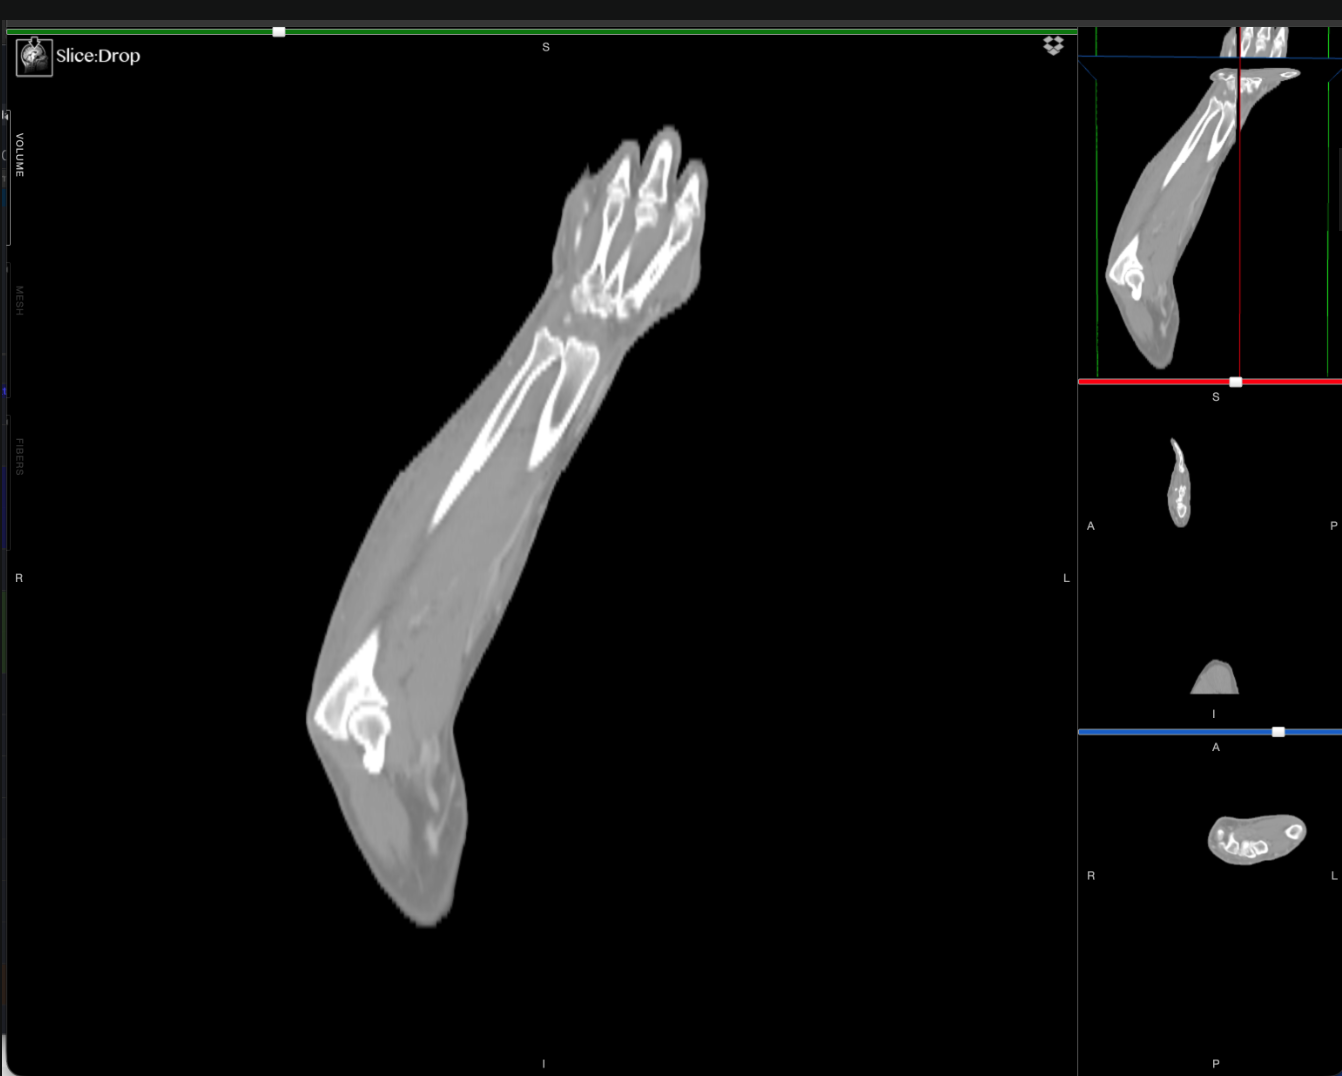

In [71]:
from IPython.display import Image
Image('/Users/ramihuunguyen/Desktop/Screenshot 2026-05-02 at 11.24.30 AM.png')

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

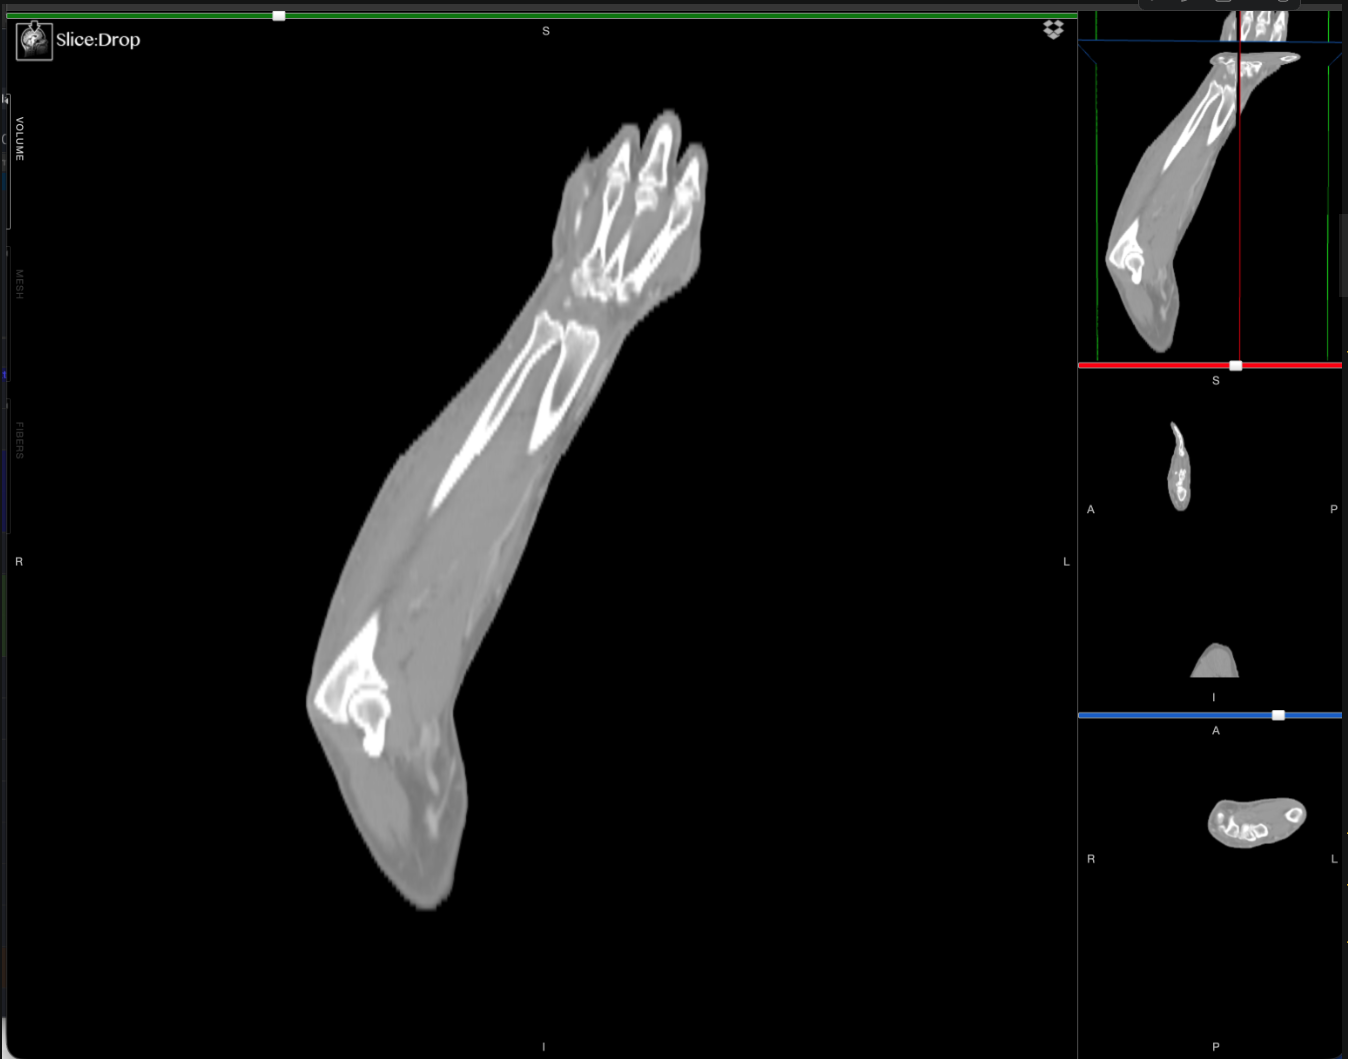

In [72]:
from IPython.display import Image
Image('/Users/ramihuunguyen/Desktop/Screenshot 2026-05-02 at 11.25.29 AM.png')

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [ ]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [ ]:
import pydicom

In [ ]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

In [25]:
dcm_dir = './ct'
dcm_filenames = sorted(os.listdir(dcm_dir))
dcm_files = [os.path.join(dcm_dir, f) for f in dcm_filenames if f.endswith('.dcm')]

first_dcm = pydicom.dcmread(dcm_files[0])
height, width = first_dcm.pixel_array.shape
num_slices = len(dcm_files)

volume = np.zeros((num_slices, height, width), dtype=first_dcm.pixel_array.dtype)

for i, dcm_file in enumerate(dcm_files):
    dcm = pydicom.dcmread(dcm_file)
    volume[i] = dcm.pixel_array

print(f"Volume shape: {volume.shape}")

Volume shape: (220, 454, 512)


In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

In [ ]:
# TODO: YOUR CODE FOR AXIAL

In [ ]:
# TODO: YOUR CODE FOR SAGITTAL

In [ ]:
# TODO: YOUR CODE FOR CORONAL

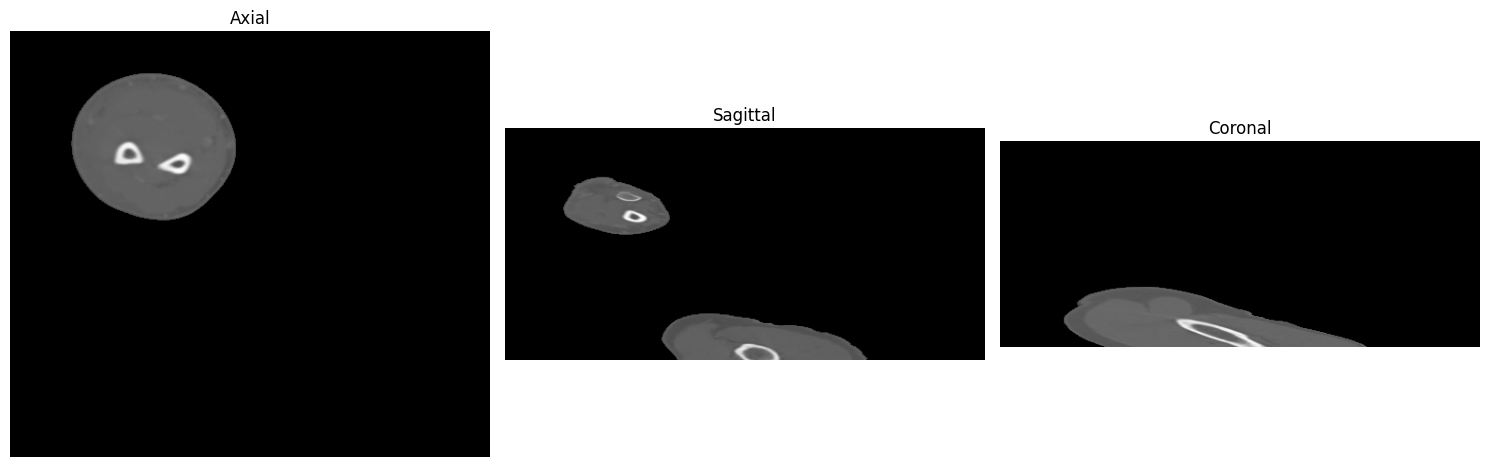

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial slice (horizontal)
axial_idx = volume.shape[0] // 2
axes[0].imshow(volume[axial_idx], cmap='gray')
axes[0].set_title('Axial')
axes[0].axis('off')

# Sagittal slice (side view)
sagittal_idx = volume.shape[2] // 2
axes[1].imshow(volume[:, :, sagittal_idx], cmap='gray')
axes[1].set_title('Sagittal')
axes[1].axis('off')

# Coronal slice (front view)
coronal_idx = volume.shape[1] // 2
axes[2].imshow(volume[:, coronal_idx, :], cmap='gray')
axes[2].set_title('Coronal')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [ ]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [18]:
# TODO: YOUR CODE

import pydicom

dcm = pydicom.dcmread(dcm_files[0])

In [19]:
window_center = dcm[0x0028, 0x1050].value
window_width = dcm[0x0028, 0x1051].value
rescale_intercept = dcm[0x0028, 0x1052].value

In [21]:
print("Window Center (Level):", window_center)
print("Window Width:", window_width)
print("Rescale Intercept:", rescale_intercept)

Window Center (Level): 30
Window Width: 410
Rescale Intercept: -1024


In [22]:
vmin = window_center - window_width / 2
vmax = window_center + window_width / 2


In [ ]:
print("vmin:", vmin, "vmax:", vmax)

vmin: -175.0 vmax: 235.0


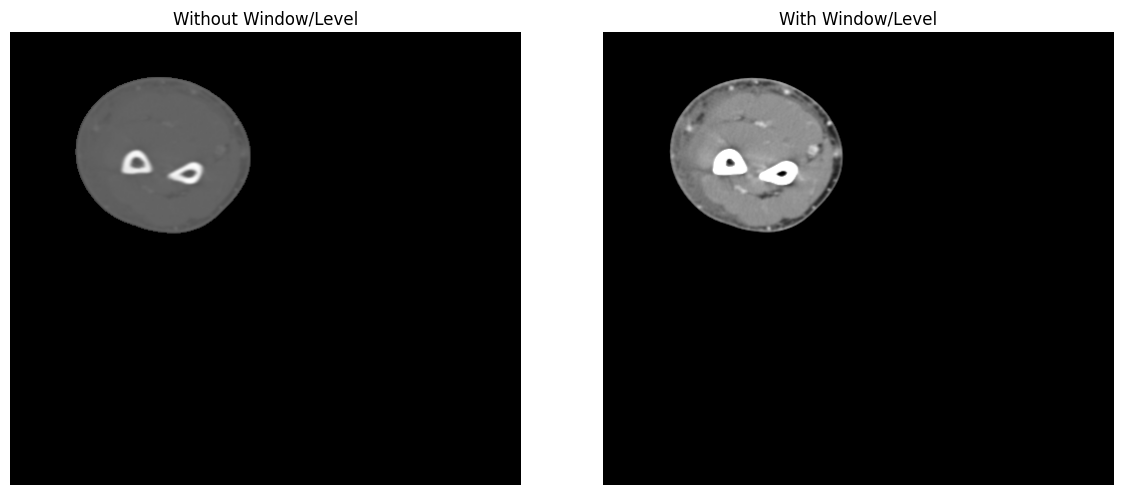

In [26]:
# Visualize one slice with window/level adjustment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Without window/level
axes[0].imshow(volume[volume.shape[0]//2], cmap='gray')
axes[0].set_title('Without Window/Level')
axes[0].axis('off')

# With window/level
axes[1].imshow(volume[volume.shape[0]//2] + rescale_intercept, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('With Window/Level')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

In [30]:
presets = {
    'Window 1': {'center': 40, 'width': 80},
    'Window 2': {'center': 400, 'width': 1000},
    'Window 3': {'center': -400, 'width': 1500},
    'Window 4': {'center': 60, 'width': 360}
}

In [31]:
print(window_center)  # This prints the HU value
print(window_width)   # This prints the HU range

30
410


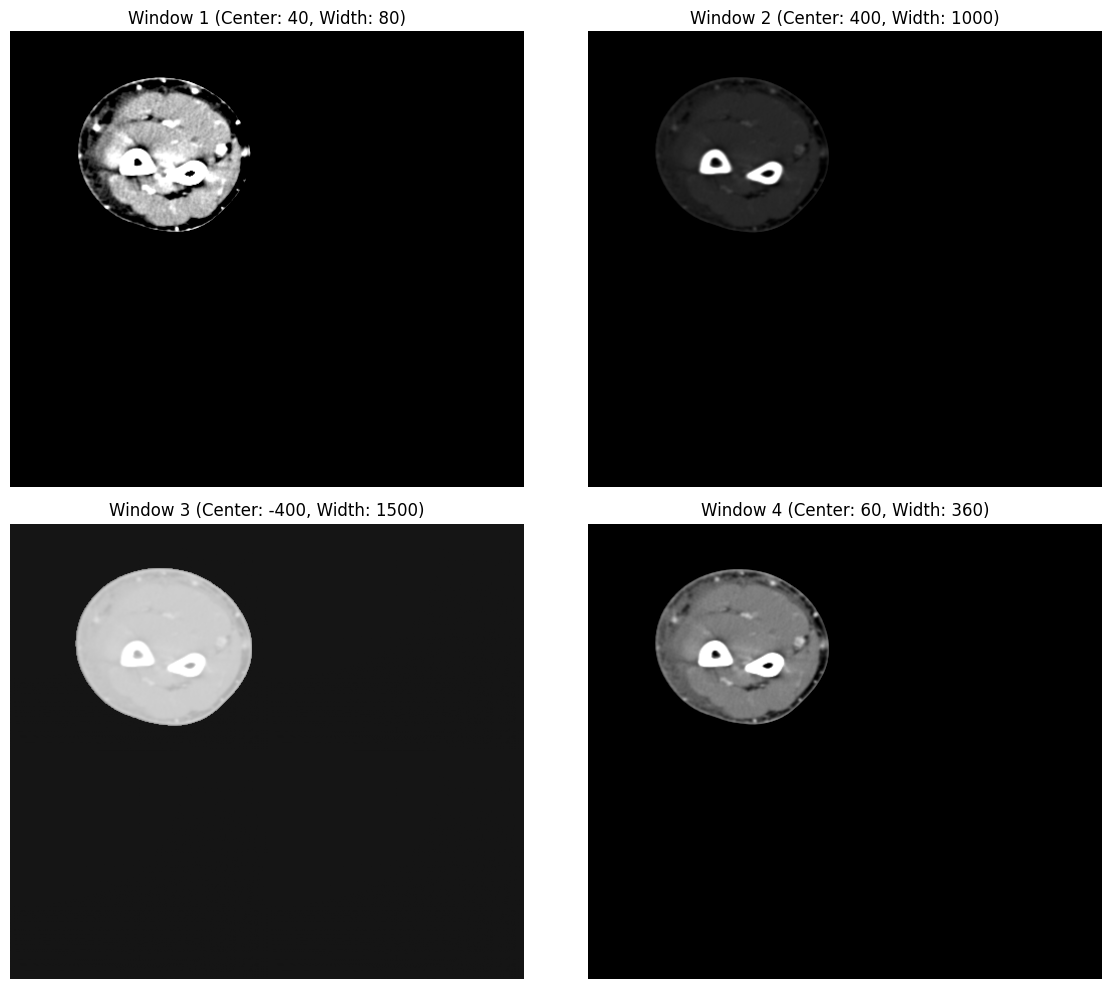

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

slice_idx = volume.shape[0] // 2

for idx, (name, values) in enumerate(presets.items()):
    center = values['center']
    width = values['width']
    vmin = center - width / 2
    vmax = center + width / 2
    
    axes[idx].imshow(volume[slice_idx] + rescale_intercept, cmap='gray', vmin=vmin, vmax=vmax)
    axes[idx].set_title(name + ' (Center: ' + str(center) + ', Width: ' + str(width) + ')')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Which values make sense and why?

In [33]:
#Window 4 is best because it shows bones and muscles together clearly.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [ ]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

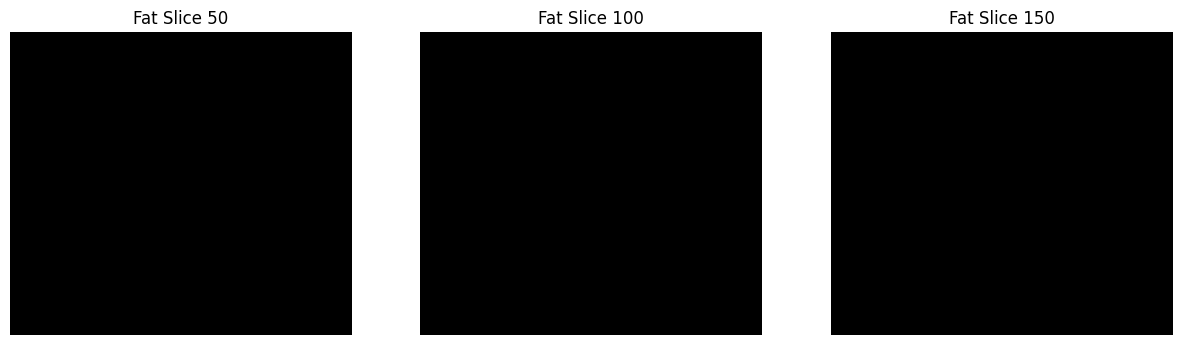

In [64]:
# Fat: 0 to 100 HU
fat_mask = volume.copy().astype(np.int16)
fat_mask[fat_mask < -150] = 0
fat_mask[fat_mask > -50] = 0

# Visualize Fat (3 slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, idx in enumerate([50, 100, 150]):
    axes[i].imshow(fat_mask[idx], cmap='gray')
    axes[i].set_title('Fat Slice ' + str(idx))
    axes[i].axis('off')
plt.show()

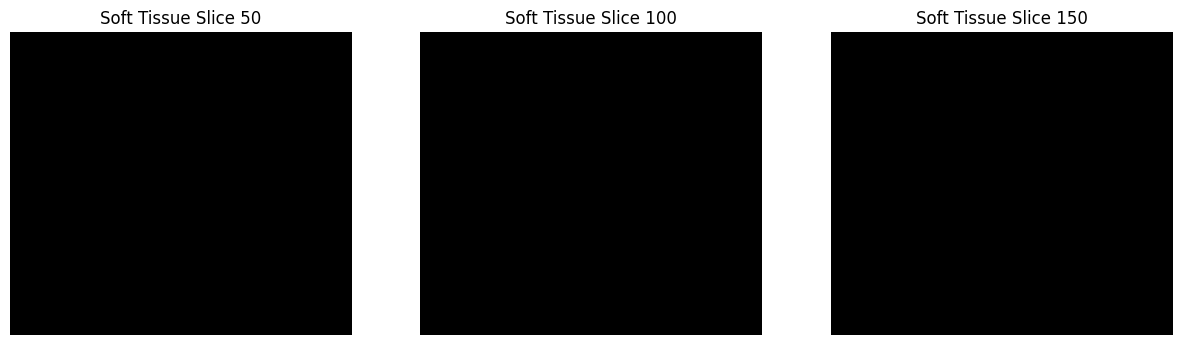

In [65]:
# Soft Tissue: -50 to 100 HU
soft_mask = volume.copy().astype(np.int16)
soft_mask[soft_mask < 20] = 0
soft_mask[soft_mask > 100] = 0

# Visualize Soft Tissue (3 slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, idx in enumerate([50, 100, 150]):
    axes[i].imshow(soft_mask[idx], cmap='gray')
    axes[i].set_title('Soft Tissue Slice ' + str(idx))
    axes[i].axis('off')
plt.show()

- The fat and soft tissue segmentations are not good as they show only black images with no visible structures. 
- The HU ranges used do not match the actual data in the volume data, so nothing is being segmented correctly.

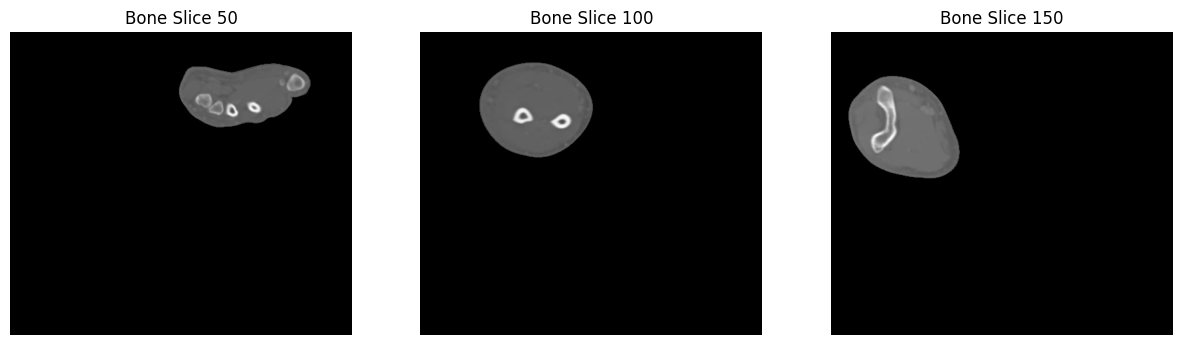

In [67]:
# Bone: 300 to 3000 HU
bone_mask = volume.copy().astype(np.int16)
bone_mask[bone_mask < 300] = 0
bone_mask[bone_mask > 3000] = 0

# Visualize Bone (3 slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, idx in enumerate([50, 100, 150]):
    axes[i].imshow(bone_mask[idx], cmap='gray')
    axes[i].set_title('Bone Slice ' + str(idx))
    axes[i].axis('off')
plt.show()

In [69]:
#The bone segmentation is good because it shows the bones clearly and separates them from the muscles around them.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""